In [ ]:
import pandas as pd
# 1. Load dataset awal
df = pd.read_csv('/content/Teen_Mental_Health_Dataset_DIRUSAK.csv')

In [ ]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instgrm,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,tik_tok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,BOTH,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,16,female,3.1,TikTok!!!,5.0,1.1,2.73,1.6,low,2,8,1,0
1256,19,female,NaN,NaN,NaN,0.8,NaN,0.5,high,3,7,7,0
1257,18,male,5.7,Both,8.4,2.4,2.84,0.7,low,5,4,9,0
1258,18,male,3.1,Instgrm,5.7,2.9,3.10,0.6,medium,9,4,2,0


In [ ]:
# Menghitung Data Kosong dan Duplikat
print(f"Jumlah baris awal sebelum dibersihkan: {len(df)}\n")

# --- Proses Missing Values (Data Kosong) ---
missing_count = df.isnull().any(axis=1).sum()
print(f"[-] Jumlah baris dengan data kosong (NaN) yang dihapus: {missing_count}")
df = df.dropna()
print(f"[>] Sisa baris setelah data kosong dihapus: {len(df)}\n")

# --- Proses Data Duplikat ---
duplicate_count = df.duplicated().sum()
print(f"[-] Jumlah baris duplikat yang dihapus: {duplicate_count}")
df = df.drop_duplicates()
print(f"[>] Sisa baris setelah data duplikat dihapus: {len(df)}\n")

# --- Ringkasan Tahap 1 ---
total_dihapus = missing_count + duplicate_count
print(f"=== Total data yang dihapus (Kosong + Duplikat): {total_dihapus} baris ===")

Jumlah baris awal sebelum dibersihkan: 1260

[-] Jumlah baris dengan data kosong (NaN) yang dihapus: 151
[>] Sisa baris setelah data kosong dihapus: 1109

[-] Jumlah baris duplikat yang dihapus: 53
[>] Sisa baris setelah data duplikat dihapus: 1056

=== Total data yang dihapus (Kosong + Duplikat): 204 baris ===


In [ ]:
# 4. GANTI/TAMBAHKAN: Standardisasi string pada kolom 'platform_usage'
# Mengubah semua teks menjadi huruf kecil agar seragam
df['platform_usage'] = df['platform_usage'].str.lower()
# Menggabungkan kategori yang maknanya sama
df['platform_usage'] = df['platform_usage'].replace({
    'instgrm': 'instagram',
    'instagram!!!': 'instagram',
    'tik_tok': 'tiktok',
    'tiktok!!!': 'tiktok',
    'both!!!': 'both'
})

In [ ]:
# Tampilkan total data sebelum masuk ke tahap IQR
print(f"Total data sebelum proses eliminasi IQR: {len(df)}\n")

# 5. Penanganan Outlier menggunakan metode IQR (Interquartile Range)
def hapus_outlier_iqr(df_input, kolom):
    print(f"--- Proses Outlier pada kolom '{kolom}' ---")

    Q1 = df_input[kolom].quantile(0.25)
    Q3 = df_input[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # Cari baris yang merupakan outlier
    outlier_kondisi = (df_input[kolom] < batas_bawah) | (df_input[kolom] > batas_atas)
    jumlah_outlier = outlier_kondisi.sum()

    print(f"Nilai Q1: {Q1:.2f} | Nilai Q3: {Q3:.2f}")
    print(f"Batas Bawah: {batas_bawah:.2f} | Batas Atas: {batas_atas:.2f}")
    print(f"[-] Jumlah Outlier yang dihapus: {jumlah_outlier}")

    # Kembalikan dataframe tanpa outlier
    df_bersih = df_input[~outlier_kondisi]
    print(f"[>] Sisa baris data saat ini: {len(df_bersih)}\n")

    return df_bersih

# Eksekusi fungsi IQR ke variabel numerik utama
df = hapus_outlier_iqr(df, 'sleep_hours')
df = hapus_outlier_iqr(df, 'age')
df = hapus_outlier_iqr(df, 'daily_social_media_hours')

# Tampilkan sisa data bersih akhir
print(f"=== TOTAL BARIS DATA BERSIH AKHIR: {len(df)} ===")

Total data sebelum proses eliminasi IQR: 1056

--- Proses Outlier pada kolom 'sleep_hours' ---
Nilai Q1: 5.20 | Nilai Q3: 7.80
Batas Bawah: 1.30 | Batas Atas: 11.70
[-] Jumlah Outlier yang dihapus: 44
[>] Sisa baris data saat ini: 1012

--- Proses Outlier pada kolom 'age' ---
Nilai Q1: 14.00 | Nilai Q3: 18.00
Batas Bawah: 8.00 | Batas Atas: 24.00
[-] Jumlah Outlier yang dihapus: 40
[>] Sisa baris data saat ini: 972

--- Proses Outlier pada kolom 'daily_social_media_hours' ---
Nilai Q1: 2.70 | Nilai Q3: 6.40
Batas Bawah: -2.85 | Batas Atas: 11.95
[-] Jumlah Outlier yang dihapus: 0
[>] Sisa baris data saat ini: 972

=== TOTAL BARIS DATA BERSIH AKHIR: 972 ===


In [ ]:
# 6. Cek dimensi akhir dataset yang sudah bersih
print("Dimensi dataset setelah data cleaning:", df.shape)

Dimensi dataset setelah data cleaning: (972, 13)


In [ ]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,tiktok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,tiktok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,13,female,7.2,instagram,8.1,2.1,2.52,0.4,medium,3,3,7,0
1194,17,male,2.0,both,4.5,1.7,2.65,0.0,medium,9,4,2,0
1196,16,male,2.3,both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,both,8.7,0.7,3.98,0.8,high,1,1,1,0


In [ ]:
# 7. MENGKONSTRUKSI DATA (Feature Encoding)
# Mengubah variabel kategorikal menjadi numerik agar bisa diproses algoritma

# a. Ordinal Encoding untuk 'social_interaction_level'
# Menggunakan urutan karena ada tingkatan: low (0), medium (1), high (2)
mapping_social = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(mapping_social)

# b. Binary Encoding untuk 'gender'
# Mengubah teks menjadi biner: female (0) dan male (1)
mapping_gender = {'female': 0, 'male': 1}
df['gender'] = df['gender'].map(mapping_gender)

# c. One-Hot Encoding untuk 'platform_usage'
# Karena platform tidak ada tingkatan (Instagram tidak lebih tinggi dari TikTok),
# kita pecah menjadi kolom biner terpisah menggunakan get_dummies
df = pd.get_dummies(df, columns=['platform_usage'], dtype=int)

# Menampilkan 5 baris teratas untuk memverifikasi perubahan
df.head()

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_ both,platform_usage_ instagram,platform_usage_ tiktok,platform_usage_both,platform_usage_instagram,platform_usage_tiktok
0,14,1,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,0,0,0,0,1,0
1,19,0,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,0,0,0,0,0,1
2,17,0,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,0,0,0,0,1,0
3,15,1,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,0,0,0,0,0,1
4,15,0,4.7,4.9,3.0,2.37,1.4,1,3,5,2,0,0,0,0,1,0,0


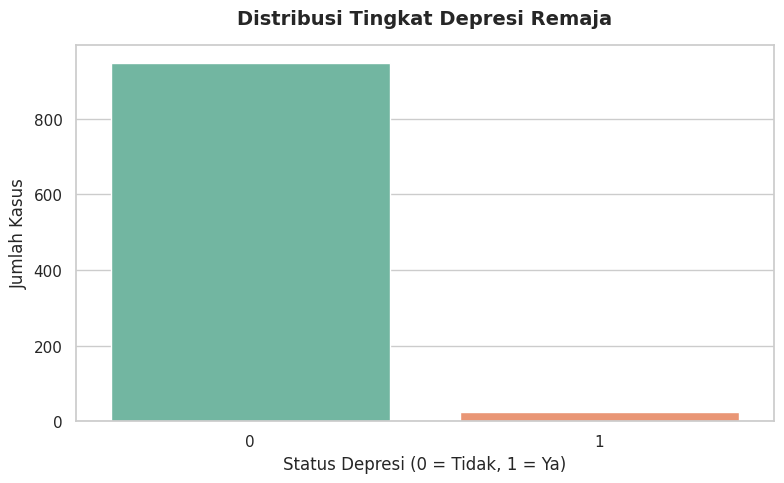

In [ ]:
# 8. MEMBUAT BUSINESS INTELLIGENCE (Visualisasi Data / EDA) - VERSI RAPI
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visual agar terlihat bersih dan profesional
sns.set_theme(style="whitegrid")

# ==========================================
# Grafik 1: Proporsi Label Depresi
# ==========================================
plt.figure(figsize=(8, 5)) # Membuat kanvas tersendiri agar lebih luas
sns.countplot(data=df, x='depression_label', palette='Set2', hue='depression_label', legend=False)
plt.title('Distribusi Tingkat Depresi Remaja', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Depresi (0 = Tidak, 1 = Ya)', fontsize=12)
plt.ylabel('Jumlah Kasus', fontsize=12)
plt.tight_layout()
plt.show()

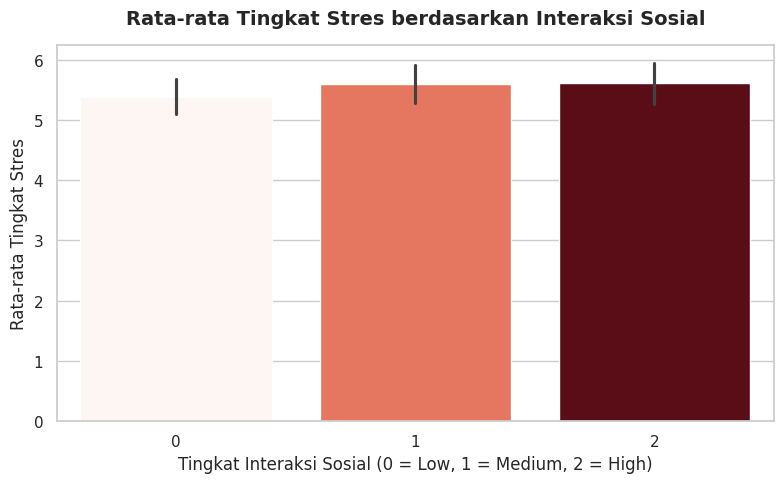

In [ ]:
# ==========================================
# Grafik 2: Hubungan Interaksi Sosial dan Tingkat Stres
# ==========================================
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='social_interaction_level', y='stress_level', palette='Reds', hue='social_interaction_level', legend=False)
plt.title('Rata-rata Tingkat Stres berdasarkan Interaksi Sosial', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tingkat Interaksi Sosial (0 = Low, 1 = Medium, 2 = High)', fontsize=12)
plt.ylabel('Rata-rata Tingkat Stres', fontsize=12)
plt.tight_layout()
plt.show()

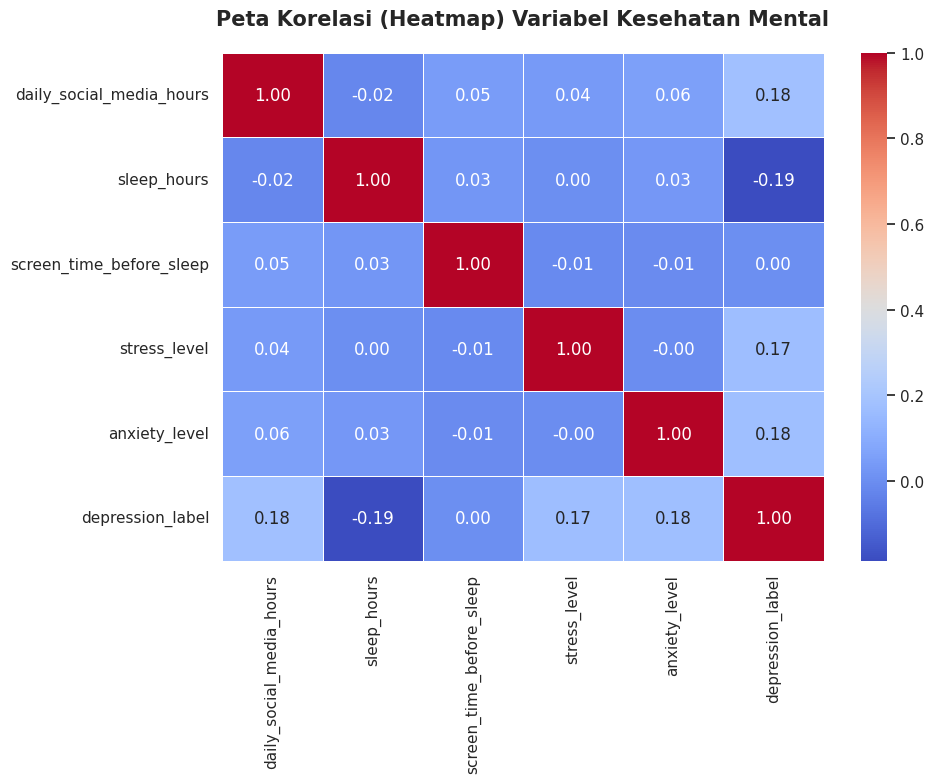

In [ ]:
# ==========================================
# Grafik 3: Heatmap Korelasi
# ==========================================
plt.figure(figsize=(10, 8))
kolom_penting = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                 'stress_level', 'anxiety_level', 'depression_label']
korelasi = df[kolom_penting].corr()

sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Peta Korelasi (Heatmap) Variabel Kesehatan Mental', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Menyimpan data yang sudah bersih ke dalam file CSV baru
# index=False digunakan agar nomor urut baris tidak ikut tersimpan sebagai kolom baru
df.to_csv('Dataset_Mental_Health_SIAP_LOOKER.csv', index=False)

# 2. Mengunduh file tersebut otomatis ke laptop/komputermu
from google.colab import files
files.download('Dataset_Mental_Health_SIAP_LOOKER.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.describe()

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_ both,platform_usage_ instagram,platform_usage_ tiktok,platform_usage_both,platform_usage_instagram,platform_usage_tiktok
count,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000,972.000000
mean,15.923868,0.512346,4.545782,6.446193,1.744856,2.995206,1.015741,0.962963,5.520576,5.609053,5.622428,0.024691,0.055556,0.058642,0.048354,0.270576,0.283951,0.282922
std,2.025168,0.500105,2.058089,1.443811,0.714643,0.578892,0.581264,0.808469,2.918493,2.855504,2.847738,0.155263,0.229179,0.235074,0.214623,0.444486,0.451145,0.450651
min,13.000000,0.000000,1.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,0.000000,2.700000,5.200000,1.100000,2.507500,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,16.000000,1.000000,4.500000,6.500000,1.800000,2.985000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,6.400000,7.625000,2.325000,3.500000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,19.000000,1.000000,8.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
